In [4]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
from astropy.io import fits
from astropy.table import Table

hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data2 = hdul[2].data  # Assuming the data is in the second extension

# Calculate apparent_mag_i from PSFFLUX (i-band is index 2)
apparent_mag_i = -2.5 * np.log10(fits_data2['PSFFLUX'][:, 2]) + 22.5

# Add apparent_mag_i as a new field to fits_data2

# Convert fits_data2 to Table, add column, convert back to FITS_rec
table_data2 = Table(fits_data2)
table_data2['apparent_mag_i'] = apparent_mag_i
fits_data2 = table_data2.as_array()

fields1 = ['RA', 'DEC', 'SDSS_NAME', 'Z_SYS', 'LOGLBOL', 'LOGLBOL_ERR', 'LOGL3000', 'LOGL3000_ERR']
fields2 = ['M_I', 'SN_MEDIAN_ALL', 'apparent_mag_i']

data = {}
for f in fields1:
    data[f] = fits_data[f]
for f in fields2:
    data[f] = fits_data2[f]

df_fits = pd.DataFrame(data)
df_fits['Z'] = df_fits['Z_SYS']

# Calculate LOGLBOL for each row in df_fits based on Z_SYS
df_fits['LOGLBOL_CALC'] = np.where(
    df_fits['Z'] < 0.7,
    np.log10(5.15) + df_fits['LOGL3000'],
    df_fits['LOGLBOL']
)
df_fits['LOGLBOL_ERR_CALC'] = np.where(
    df_fits['Z'] < 0.7,
    df_fits['LOGL3000_ERR'],
    df_fits['LOGLBOL_ERR']
)

df_fits['LOGLBOL'] = df_fits['LOGLBOL_CALC']
df_fits['LOGLBOL_ERR'] = df_fits['LOGLBOL_ERR_CALC']


/tmp/ipykernel_2986038/316102214.py:9: RuntimeWarning: divide by zero encountered in log10
  apparent_mag_i = -2.5 * np.log10(fits_data2['PSFFLUX'][:, 2]) + 22.5
/tmp/ipykernel_2986038/316102214.py:9: RuntimeWarning: invalid value encountered in log10
  apparent_mag_i = -2.5 * np.log10(fits_data2['PSFFLUX'][:, 2]) + 22.5


In [75]:
df_fits['apparent_mag_i']

0         18.429550
1         21.564869
2         21.858921
3         21.756798
4         18.499804
            ...    
750409    21.360281
750410    19.778624
750411    18.611536
750412    20.268217
750413    20.567568
Name: apparent_mag_i, Length: 750414, dtype: float32

In [77]:
from astropy.coordinates import search_around_sky
from astropy.table import join

cat = pd.read_parquet(f"data/S82/Catalog.parquet").set_index('idx')

df_cat = cat.reset_index()[['objectId', 'RA', 'DEC']]
df_cat = df_cat.rename(columns={'RA': 'RA_w', 'DEC': 'DEC_w'})

# SkyCoord for both catalogs (assumes RA/DEC are in degrees)
coords_cat  = SkyCoord(ra=df_cat['RA_w'].values * u.deg, dec=df_cat['DEC_w'].values * u.deg)
coords_fits = SkyCoord(ra=df_fits['RA'].values    * u.deg, dec=df_fits['DEC'].values    * u.deg)

# All matches within 1 arcsec
idx_cat, idx_fits, sep2d, _ = search_around_sky(coords_cat, coords_fits, 1 * u.arcsec)

# Give df_fits a key to merge on
df_fits = df_fits.copy()
df_fits['idx'] = np.arange(len(df_fits))

# Take only the matched rows from df_cat (use iloc!), attach the matching df_fits index
df_cat_match = df_cat.iloc[idx_cat].reset_index(drop=True).copy()
df_cat_match['idx'] = idx_fits
df_cat_match['sep_arcsec'] = sep2d.to(u.arcsec).value  # handy to keep

# Inner join: repeats df_fits rows if there are multiple cat matches (expected behavior)
df_merged = pd.merge(df_fits, df_cat_match, on='idx', how='inner')

In [65]:
combined[combined['objectId'] == '1446436'][['objectId', 'RA', 'Z', 'LOGLBOL']]

,objectId,RA,Z,LOGLBOL
37677,1446436,357.392846,2.139497,46.106453


In [78]:
df = pd.read_csv('data/sample_chisqg10_ebv005sn3_fittedm2500.csv', dtype={'object_id': str})

df_merged_final = pd.merge(df, df_merged, left_on='object_id', right_on='objectId', how='inner')
df_merged_final = df_merged_final[df_merged_final['LOGLBOL'] > 43]

df_merged_final.to_csv('data/sample_chisqg10_ebv005sn3_merged_radec.csv', index=False)

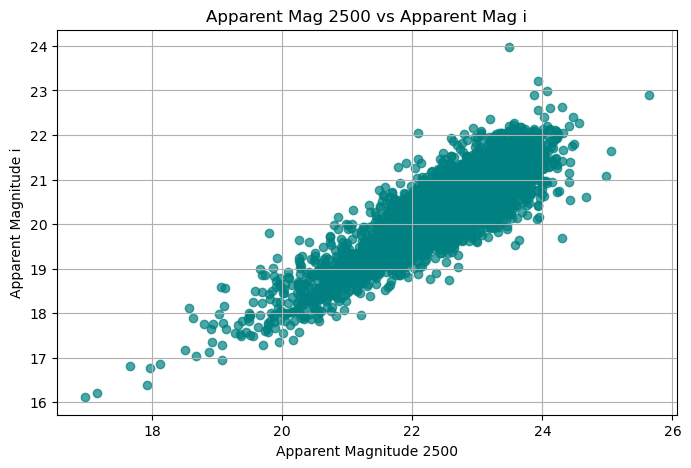

In [81]:
plt.figure(figsize=(8, 5))
mask = (df_merged_final['apparent_mag_2500'] > 0) & (df_merged_final['apparent_mag_i'] < 27)
plt.scatter(df_merged_final['apparent_mag_2500'][mask], df_merged_final['apparent_mag_i'][mask], alpha=0.7, color='teal')
plt.xlabel('Apparent Magnitude 2500')
plt.ylabel('Apparent Magnitude i')
plt.title('Apparent Mag 2500 vs Apparent Mag i')
plt.grid(True)
plt.show()

In [94]:
df_merged_final['ra'] = df_merged_final['RA']
df_merged_final['dec'] = df_merged_final['DEC']
df_merged_final[df_merged_final['alpha_lambda'] < -10].head(50).to_csv('m2500_invalid.csv', index=False)


In [98]:
df_merged_final[df_merged_final['sdss_name'] == '220832.97+002201.6'][['LOGMBH']]

KeyError: "None of [Index(['LOGMBH'], dtype='object')] are in the [columns]"

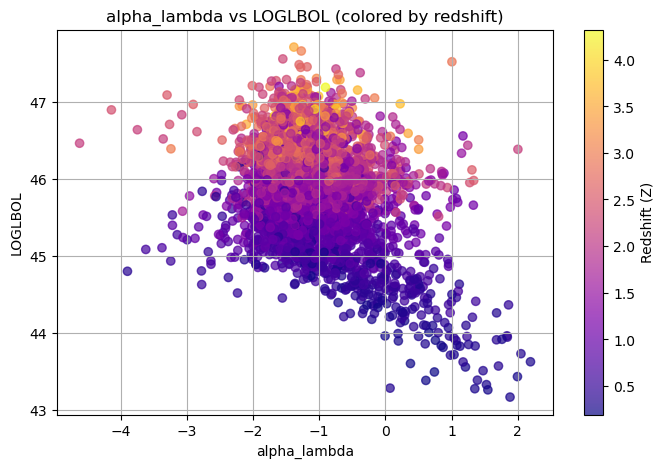

In [95]:
plt.figure(figsize=(8, 5))
mask = (df_merged_final['apparent_mag_2500'] > 0) & (df_merged_final['apparent_mag_i'] < 27) & (df_merged_final['alpha_lambda'] > -10)
sc = plt.scatter(
    df_merged_final['alpha_lambda'][mask],
    df_merged_final['LOGLBOL'][mask],
    c=df_merged_final['Z'][mask],
    cmap='plasma',
    alpha=0.7
)
plt.xlabel('alpha_lambda')
plt.ylabel('LOGLBOL')
plt.title('alpha_lambda vs LOGLBOL (colored by redshift)')
plt.colorbar(sc, label='Redshift (Z)')
plt.grid(True)
plt.savefig('plots/ancillary/alpha_lambda_vs_LOGLBOL_colorZ.png', dpi=300)
plt.show()

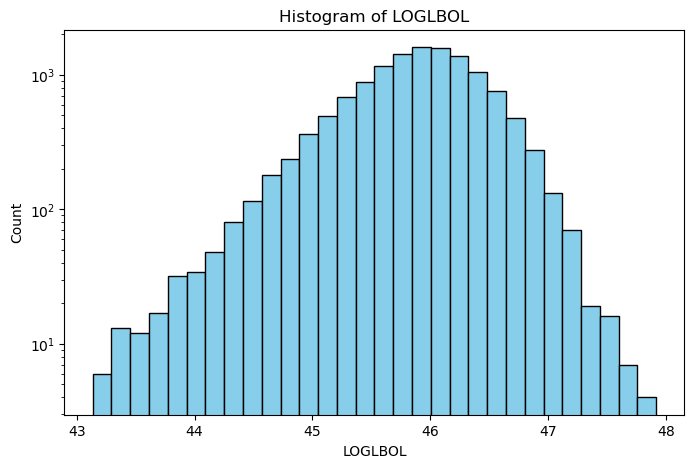

In [46]:
plt.figure(figsize=(8, 5))
plt.hist(df_merged_final['LOGLBOL'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('LOGLBOL')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Histogram of LOGLBOL')
plt.show()

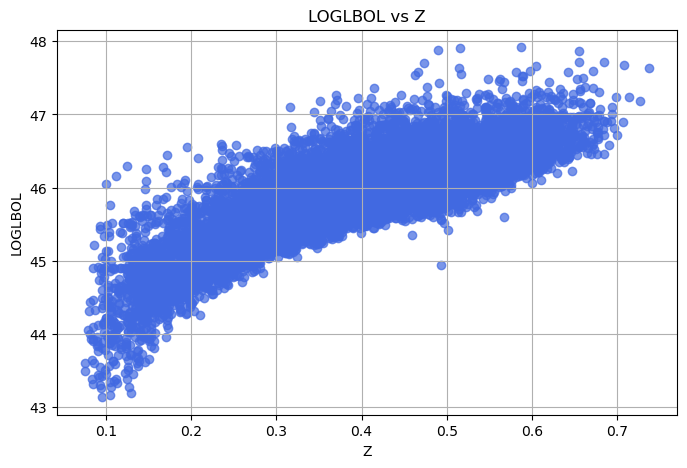

In [51]:
plt.figure(figsize=(8, 5))
plt.scatter(np.log10(1+df_merged_final['Z']), df_merged_final['LOGLBOL'], color='royalblue', alpha=0.7)
plt.xlabel('Z')
plt.ylabel('LOGLBOL')
plt.title('LOGLBOL vs Z')
plt.grid(True)
plt.show()

In [ ]:
bin_edges = np.linspace(df_merged_final['LOGLBOL'].min(), df_merged_final['LOGLBOL'].max(), 6)
print("Bin edges:", bin_edges)
df_merged_final['LOGLBOL_bin'] = pd.cut(df_merged_final['LOGLBOL'], bins=bin_edges)

for i, (bin_label, group) in enumerate(df_merged_final.groupby('LOGLBOL_bin')):
    group_shuffled = group.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Processing bin: {i} {bin_label} with {len(group_shuffled)} entries")
    group_shuffled.to_csv(f'data/lbol_bins/sample_chisqg10_ebv005sn3_{i}.csv', index=False)


Bin edges: [43.13422365 43.6658208  44.19741795 44.7290151  45.26061225 45.79220939
 46.32380654 46.85540369 47.38700084 47.91859799]
Processing bin: 0 (43.134, 43.666] with 37 entries
Processing bin: 1 (43.666, 44.197] with 105 entries
Processing bin: 2 (44.197, 44.729] with 395 entries
Processing bin: 3 (44.729, 45.261] with 1290 entries
Processing bin: 4 (45.261, 45.792] with 3484 entries
Processing bin: 5 (45.792, 46.324] with 5044 entries
Processing bin: 6 (46.324, 46.855] with 2400 entries
Processing bin: 7 (46.855, 47.387] with 380 entries
Processing bin: 8 (47.387, 47.919] with 29 entries


/tmp/ipykernel_2986038/2773937194.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (bin_label, group) in enumerate(df_merged_final.groupby('LOGLBOL_bin')):
